<a href="https://colab.research.google.com/github/Tymon2115/CDA_Case2/blob/main/Case2_CDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In case we would like to drop one from each very highly correlated pairs:

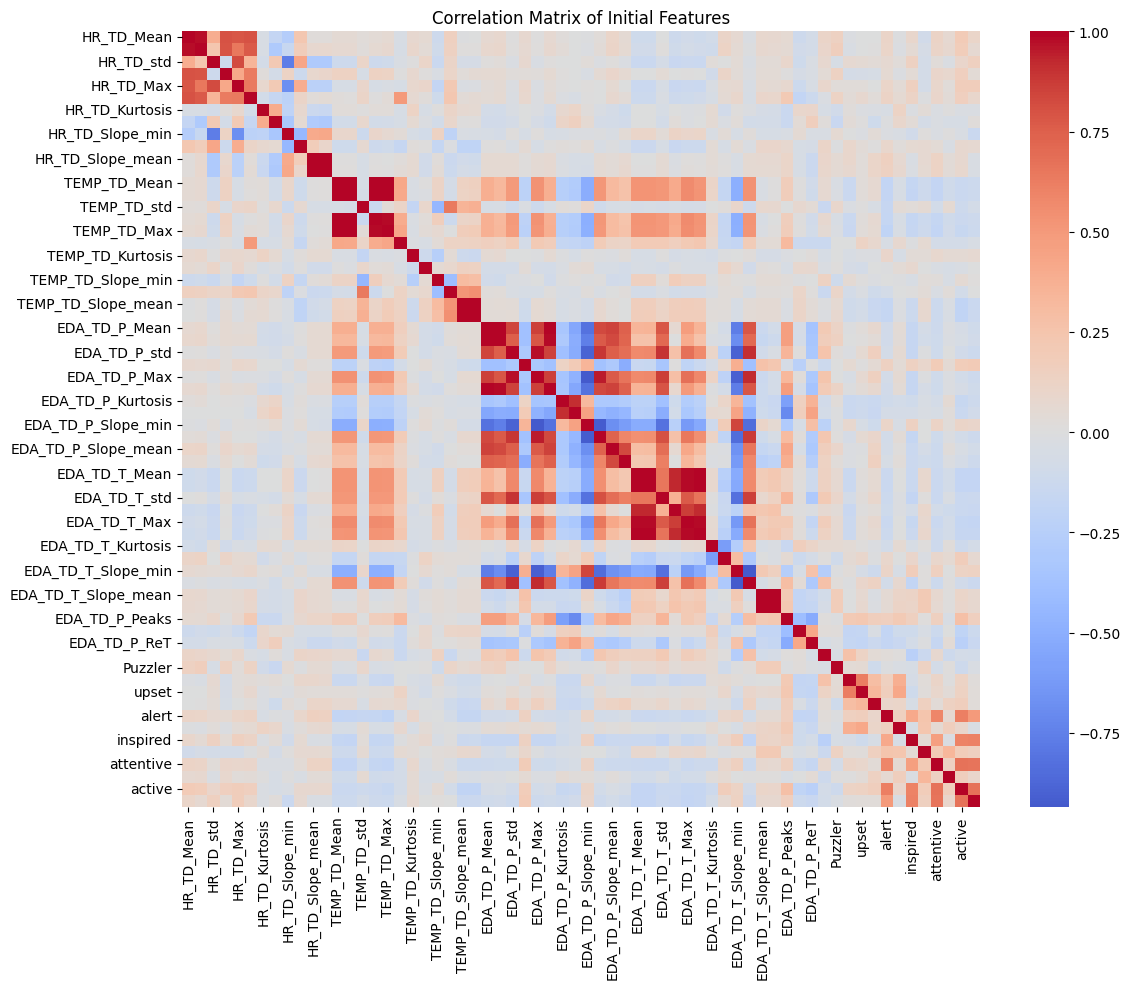

Variables to drop due to high correlation:
{'EDA_TD_P_Slope_max', 'HR_TD_Slope_mean', 'HR_TD_Mean', 'EDA_TD_P_Mean', 'TEMP_TD_Min', 'EDA_TD_P_std', 'EDA_TD_T_AUC', 'HR_TD_Max', 'EDA_TD_P_Median', 'HR_TD_std', 'EDA_TD_T_Median', 'HR_TD_AUC', 'EDA_TD_P_Slope_min', 'EDA_TD_P_Skew', 'TEMP_TD_Slope', 'EDA_TD_T_Slope_mean', 'EDA_TD_P_Max', 'EDA_TD_T_std', 'EDA_TD_T_Slope_min', 'HR_TD_Median', 'EDA_TD_T_Slope_max', 'EDA_TD_T_Mean', 'TEMP_TD_Mean', 'TEMP_TD_Median', 'EDA_TD_P_Slope_mean', 'EDA_TD_T_Max', 'EDA_TD_P_AUC'}


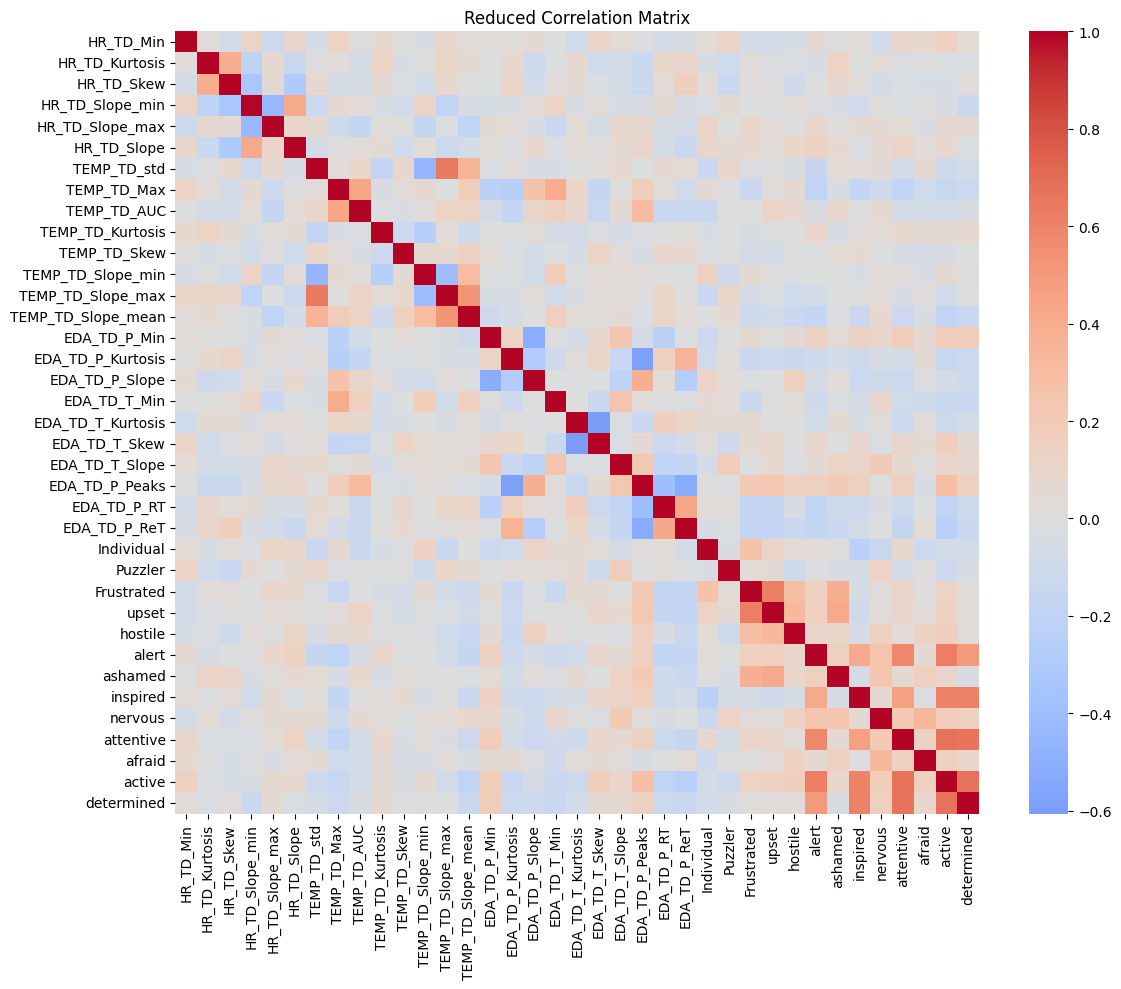

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/CDA/HR_data.csv")

df = df.iloc[:, 1:]

df_clean = df.dropna()

numeric_df = df_clean.select_dtypes(include=["float64", "int64"])
non_numeric_df = df_clean.select_dtypes(exclude=["float64", "int64"])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Initial Features")
plt.tight_layout()
plt.show()

corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.7:
            if corr_matrix[col].mean() > corr_matrix[row].mean():
                to_drop.add(col)
            else:
                to_drop.add(row)

print("Variables to drop due to high correlation:")
print(to_drop)

reduced_numeric_df = numeric_df.drop(columns=to_drop)

df_final = pd.concat([non_numeric_df.reset_index(drop=True), reduced_numeric_df.reset_index(drop=True)], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(reduced_numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Reduced Correlation Matrix")
plt.tight_layout()
plt.show()

# PCA analysis on biosignals

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

physio_features = [col for col in df_final.columns if col.startswith(('HR_', 'EDA_', 'TEMP_'))]
X_physio = df_final[physio_features]
scaler = StandardScaler()
X_physio_scaled = scaler.fit_transform(X_physio)
pca = PCA(n_components=2).fit(X_physio_scaled)
loadings = pd.Series(np.abs(pca.components_[0]), index=physio_features).sort_values(ascending=False)

print(loadings)

EDA_TD_P_Peaks        0.445954
EDA_TD_P_ReT          0.373433
EDA_TD_P_Kurtosis     0.371828
EDA_TD_P_Slope        0.285041
TEMP_TD_Max           0.262302
TEMP_TD_AUC           0.256873
EDA_TD_P_RT           0.240209
HR_TD_Skew            0.239320
HR_TD_Kurtosis        0.188826
HR_TD_Slope_min       0.175184
HR_TD_Slope           0.173376
EDA_TD_T_Min          0.150958
EDA_TD_T_Slope        0.132208
EDA_TD_P_Min          0.105255
TEMP_TD_Slope_min     0.102079
TEMP_TD_std           0.084075
HR_TD_Slope_max       0.082964
TEMP_TD_Slope_max     0.082498
HR_TD_Min             0.069194
EDA_TD_T_Kurtosis     0.067767
TEMP_TD_Skew          0.050289
TEMP_TD_Kurtosis      0.036533
TEMP_TD_Slope_mean    0.015309
EDA_TD_T_Skew         0.001659
dtype: float64


##Clustering based on Kurtosis

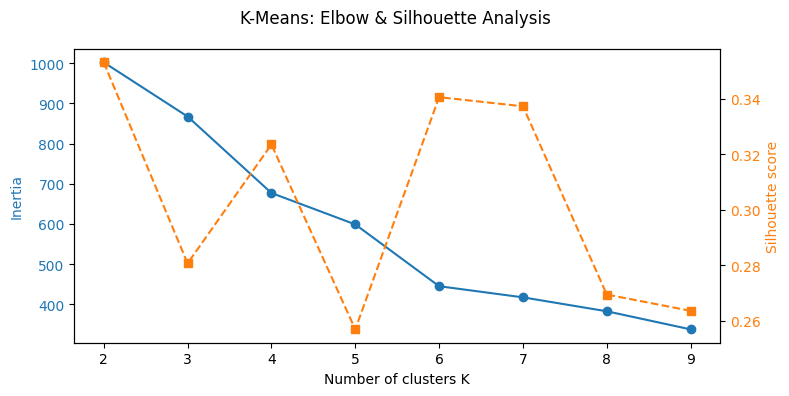

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

features = ['HR_TD_Kurtosis', 'TEMP_TD_Kurtosis', 'EDA_TD_P_Kurtosis', 'EDA_TD_T_Kurtosis']
X = df_final[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_range, inertia, 'o-', label='Inertia')
ax1.set_xlabel('Number of clusters K')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 's--', color='tab:orange', label='Silhouette')
ax2.set_ylabel('Silhouette score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.suptitle('K-Means: Elbow & Silhouette Analysis')
fig.tight_layout()
plt.show()

     Round   Phase Cohort  HR_TD_Min  HR_TD_Kurtosis  HR_TD_Skew  \
0  round_3  phase3   D1_4      67.25       -1.091448    0.369955   
1  round_3  phase2   D1_4      69.82       -0.245338    0.338732   
2  round_3  phase1   D1_4      72.22       -0.615922   -0.233047   
3  round_2  phase3   D1_4      69.42       -0.866610   -0.046021   
4  round_2  phase2   D1_4      64.95        0.200401   -0.560948   

   HR_TD_Slope_min  HR_TD_Slope_max  HR_TD_Slope  TEMP_TD_std  ...  alert  \
0          -0.7300           0.9775     0.046701     0.163895  ...    2.0   
1          -0.3600           0.1900    -0.024148     0.083766  ...    3.0   
2          -0.6300           0.3575    -0.026008     0.078038  ...    2.0   
3          -0.4650           0.6500     0.021477     0.366089  ...    2.0   
4          -0.3725           0.3375    -0.012871     0.110119  ...    3.0   

   ashamed  inspired  nervous  attentive  afraid  active  determined  cluster  \
0      1.0       2.0      2.0        3.0     1.

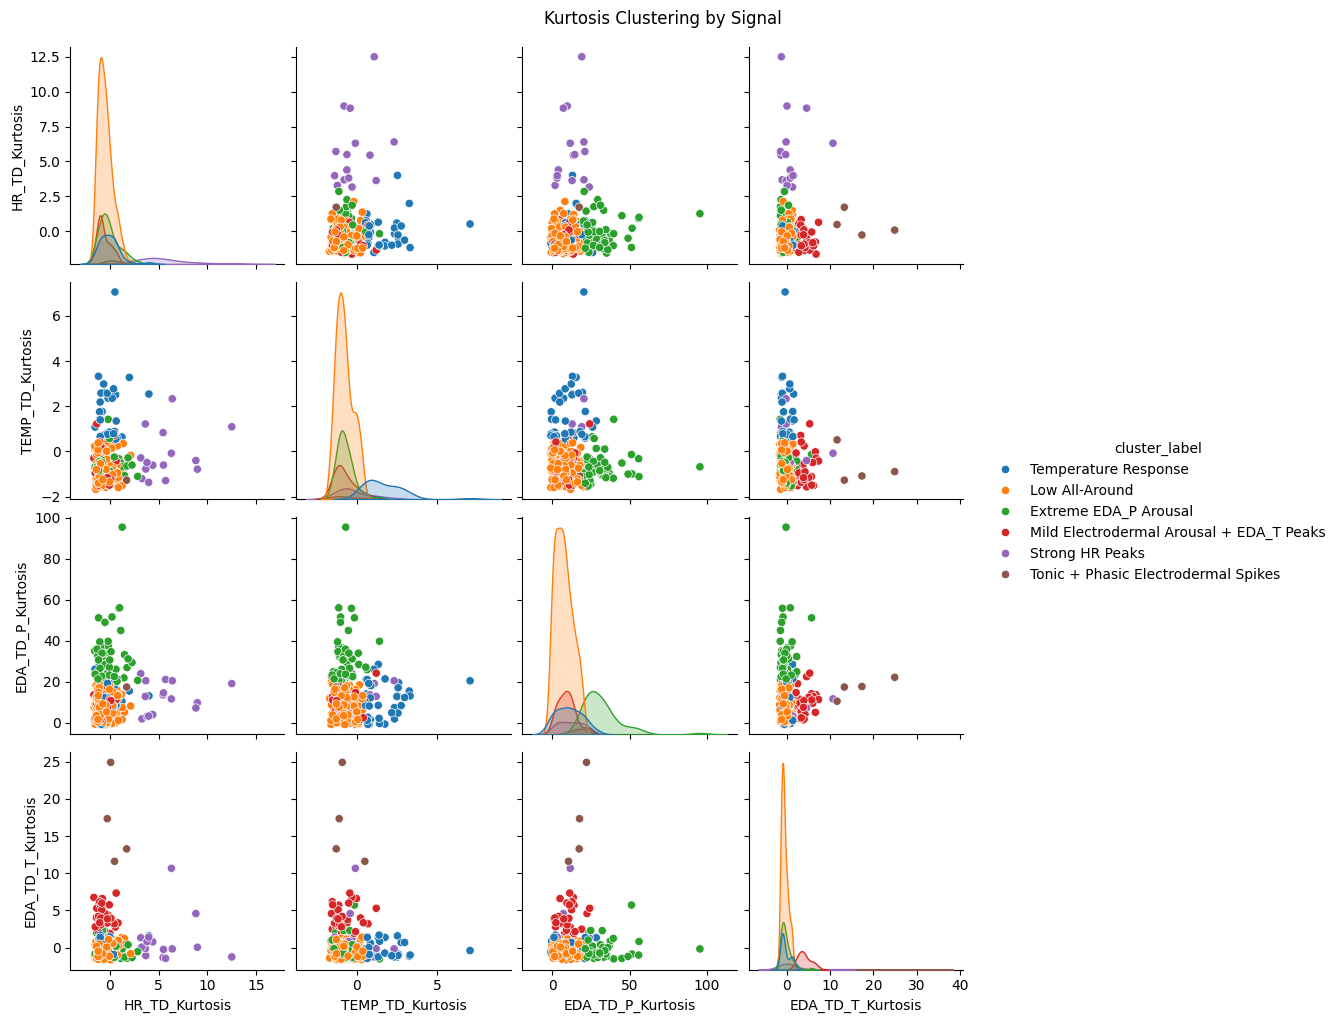

cluster_label  Extreme EDA_P Arousal  Low All-Around  \
Phase                                                  
phase1                            27              52   
phase2                             6              68   
phase3                            20              46   

cluster_label  Mild Electrodermal Arousal + EDA_T Peaks  Strong HR Peaks  \
Phase                                                                      
phase1                                                3                8   
phase2                                               13                2   
phase3                                               17                6   

cluster_label  Temperature Response  Tonic + Phasic Electrodermal Spikes  
Phase                                                                     
phase1                            8                                    2  
phase2                           14                                    1  
phase3                           13   

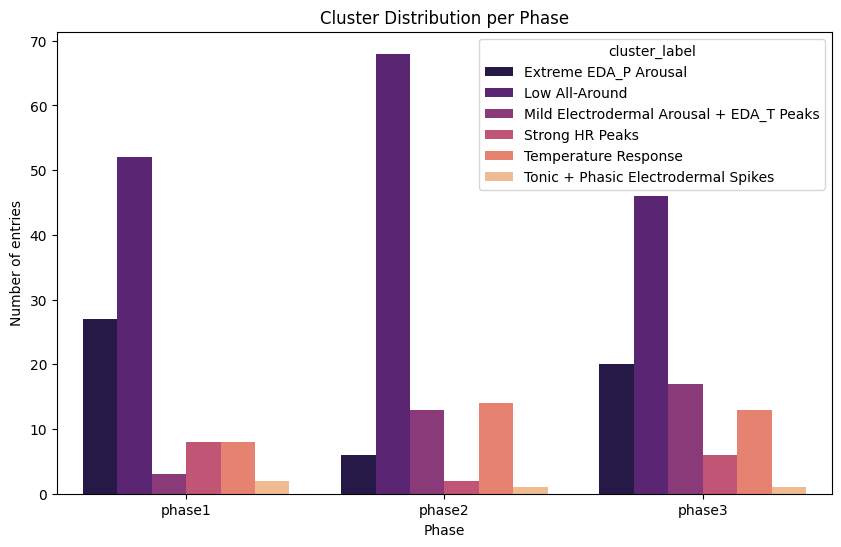

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
df_kurtosis = df_final.copy()
df_kurtosis['cluster'] = kmeans.fit_predict(X_scaled)

cluster_labels = {
    0: "Mild Electrodermal Arousal + EDA_T Peaks",
    1: "Extreme EDA_P Arousal",
    2: "Low All-Around",
    3: "Strong HR Peaks",
    4: "Tonic + Phasic Electrodermal Spikes",
    5: "Temperature Response"
}

df_kurtosis['cluster_label'] = df_kurtosis['cluster'].map(cluster_labels)
print(df_kurtosis.head())

sns.pairplot(df_kurtosis, hue='cluster_label', vars=features)
plt.suptitle("Kurtosis Clustering by Signal", y=1.02)
plt.show()

phase_cluster_counts = df_kurtosis.groupby(['Phase', 'cluster_label']).size().unstack(fill_value=0)
print(phase_cluster_counts)

cluster_summary = df_kurtosis.groupby('cluster')[['HR_TD_Kurtosis', 'TEMP_TD_Kurtosis', 'EDA_TD_P_Kurtosis', 'EDA_TD_T_Kurtosis']].mean()
print(cluster_summary)

df_long = df_kurtosis.groupby(['Phase', 'cluster_label']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_long, x='Phase', y='count', hue='cluster_label', palette='magma')
plt.title('Cluster Distribution per Phase')
plt.ylabel('Number of entries')
plt.show()

# Clustering on EDA features

Label: Puzzler

Model: K-Medoids

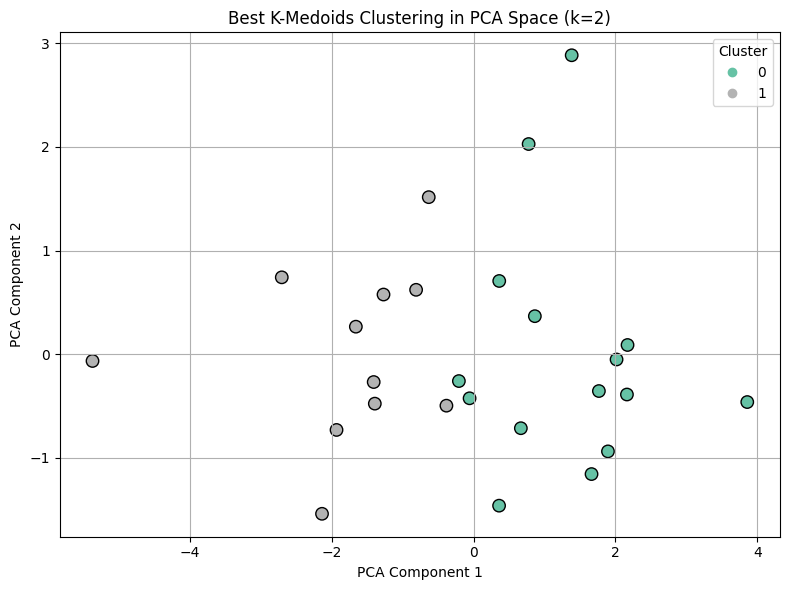

(2, np.float64(0.29952143829204453))

In [ ]:
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin_min, silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ["EDA_TD_P_Peaks", "EDA_TD_P_Kurtosis"]

# Filter and structure the dataset
df_EDA = df_final[["Individual", "Phase", "Round"] + features]
grouped = df_EDA.groupby(["Individual", "Phase"]).mean(numeric_only=True).reset_index()
pivot_df = grouped.pivot_table(index="Individual", columns="Phase", values=features)
pivot_df.columns = [f"{col}_{phase}" for col, phase in pivot_df.columns]
pivot_df = pivot_df.reset_index()

# Scale the data
X = pivot_df.drop(columns="Individual")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Re-define custom K-Medoids
def custom_k_medoids(X, n_clusters, max_iter=300, random_state=42):
    np.random.seed(random_state)
    m, n = X.shape
    medoid_indices = np.random.choice(m, n_clusters, replace=False)
    medoids = X[medoid_indices]
    for _ in range(max_iter):
        labels = pairwise_distances_argmin_min(X, medoids)[0]
        new_medoids = np.copy(medoids)
        for i in range(n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            distances = pairwise_distances(cluster_points, cluster_points)
            total_distances = distances.sum(axis=1)
            new_medoid_index = np.argmin(total_distances)
            new_medoids[i] = cluster_points[new_medoid_index]
        if np.all(medoids == new_medoids):
            break
        medoids = new_medoids
    final_labels = pairwise_distances_argmin_min(X, medoids)[0]
    return final_labels

# Evaluate for best silhouette score
best_score = -1
best_k = None
best_labels = None

for k in range(2, 15):
    labels = custom_k_medoids(X_scaled, n_clusters=k)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k
        best_labels = labels

# Visualize the result
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='Set2', s=80, edgecolors='k')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Best K-Medoids Clustering in PCA Space (k={best_k})")
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

best_k, best_score

Puzzler count per cluster:
Cluster  Puzzler
0        1          107
         0           71
1        0           81
         1           48
Name: count, dtype: int64

Cluster sizes:
Cluster
0    178
1    129
Name: count, dtype: int64
Chi-squared statistic: 14.792103530669038
p-value: 0.00012003709150633632


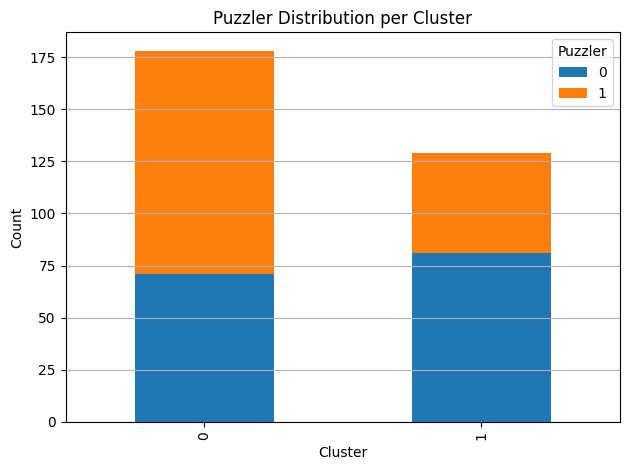

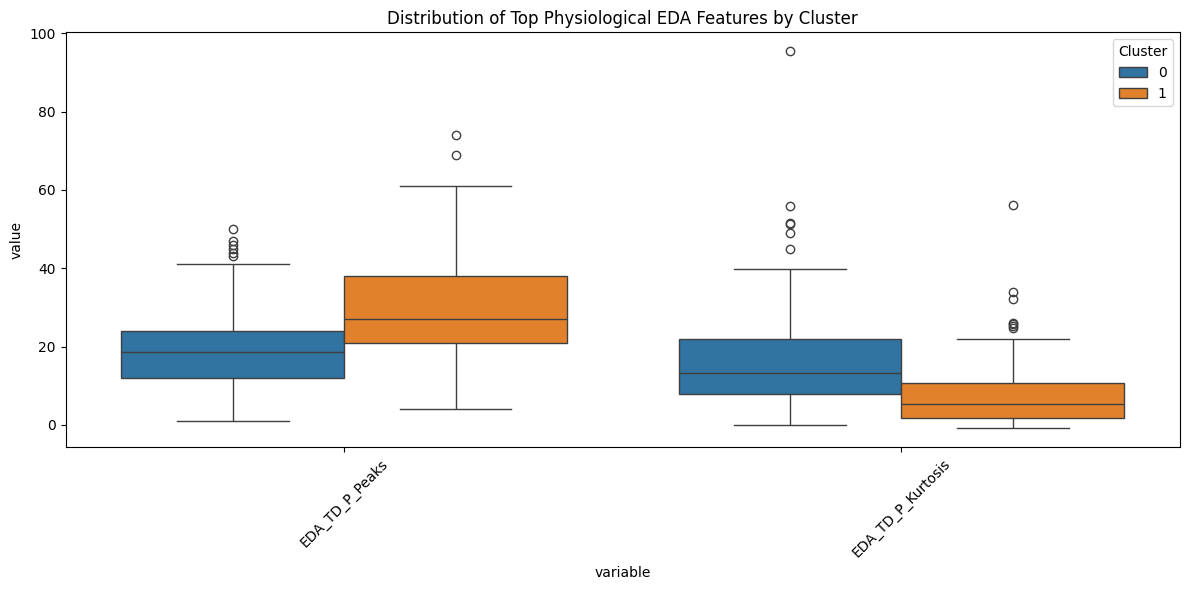

In [ ]:
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

cluster_assignments = pd.DataFrame({
    "Individual": pivot_df["Individual"],
    "Cluster": best_labels
})

df_with_clusters = pd.merge(df_final, cluster_assignments, on="Individual", how="left")

# Summary statistics
print("Puzzler count per cluster:")
print(df_with_clusters.groupby("Cluster")["Puzzler"].value_counts())
print()

print("Cluster sizes:")
print(df_with_clusters["Cluster"].value_counts())

contingency_table = pd.crosstab(df_with_clusters["Cluster"], df_with_clusters["Puzzler"])

# Run Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared statistic:", chi2)
print("p-value:", p)

contingency_table.plot(kind='bar', stacked=True)
plt.title("Puzzler Distribution per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Puzzler")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

df_with_clusters = df_clean.merge(pivot_df[["Individual"]].assign(Cluster=best_labels), on="Individual", how="left")

features_to_plot = features
melted = df_with_clusters.melt(id_vars=["Cluster"], value_vars=features_to_plot)

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="variable", y="value", hue="Cluster")
plt.title("Distribution of Top Physiological EDA Features by Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Clustering to find groups more reactive to stress

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving HR_data.csv to HR_data.csv


In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv('HR_data.csv')

puzzle_df = df[
    df['Phase'].astype(str)
      .str.strip()
      .str.lower()
      == 'phase2'
].copy()
print("Puzzle-phase rows:", puzzle_df.shape)


group_key = 'Individual'
meta_cols = [c for c in ['Puzzler', 'Cohort'] if c in puzzle_df.columns]
print("Metadata columns:", meta_cols)

numeric_cols = (
    puzzle_df
    .select_dtypes(include=[np.number])
    .columns
    .difference([group_key] + meta_cols + ['Unnamed: 0'])
    .tolist()
)
print("Numeric columns to aggregate:", len(numeric_cols))

agg_phy = (
    puzzle_df
    .groupby(group_key)[numeric_cols]
    .mean()
    .reset_index()
)

if meta_cols:
    agg_meta = (
        puzzle_df
        .groupby(group_key)[meta_cols]
        .first()
        .reset_index()
    )
    agg_df = pd.merge(agg_phy, agg_meta, on=group_key)
else:
    agg_df = agg_phy.copy()

print("Aggregated DataFrame shape:", agg_df.shape)
display(agg_df.head())


expected_emotions = [
    "Frustrated", "upset", "hostile",
    "alert", "ashamed", "inspired",
    "nervous", "attentive", "afraid",
    "active", "determined"
]
emotion_cols = [c for c in expected_emotions if c in agg_df.columns]
print("Emotion columns:", emotion_cols)

# 2. Physiological feature inputs = everything except group_key + meta + emotions
physio_cols = [
    c for c in agg_df.columns
    if c not in ([group_key] + meta_cols + emotion_cols)
]
print("Physiological inputs:", len(physio_cols), "columns")

X   = agg_df[physio_cols].copy()
aux = agg_df[[group_key] + meta_cols + emotion_cols].copy()

print("X shape:", X.shape)
print("aux shape:", aux.shape)
display(aux.head())


Puzzle-phase rows: (104, 68)
Metadata columns: ['Puzzler', 'Cohort']
Numeric columns to aggregate: 62
Aggregated DataFrame shape: (26, 65)


,Individual,EDA_TD_P_AUC,EDA_TD_P_Kurtosis,EDA_TD_P_Max,EDA_TD_P_Mean,EDA_TD_P_Median,EDA_TD_P_Min,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT,...,alert,ashamed,attentive,determined,hostile,inspired,nervous,upset,Puzzler,Cohort
0,1,1.394200,26.167020,0.022650,0.001100,0.000076,-0.000863,16.75,1.937369,2.052016,...,2.25,1.75,3.25,3.25,1.00,2.50,2.25,2.00,1,D1_4
1,2,290.182450,4.154340,1.351653,0.229599,0.121726,0.000000,32.50,1.935707,1.656207,...,1.75,1.00,3.00,4.50,1.00,3.00,1.00,1.00,0,D1_4
2,3,114.234736,4.268931,0.519752,0.090439,0.055678,-0.001681,38.25,1.903048,1.814105,...,4.00,1.25,4.75,5.00,1.00,4.75,1.00,1.25,1,D1_4
3,4,877.188407,3.018744,3.384588,0.697018,0.465595,-0.013727,41.00,1.568600,1.554798,...,4.00,1.00,3.25,3.00,1.00,3.50,2.25,1.00,0,D1_4
4,5,687.195224,8.418619,3.769016,0.546609,0.393956,0.000000,31.50,2.121259,1.758533,...,3.00,1.25,4.00,3.75,1.75,2.50,2.25,1.75,0,D1_6


Emotion columns: ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
Physiological inputs: 51 columns
X shape: (26, 51)
aux shape: (26, 14)


,Individual,Puzzler,Cohort,Frustrated,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,1,1,D1_4,2.00,2.00,1.00,2.25,1.75,2.50,2.25,3.25,1.5,3.25,3.25
1,2,0,D1_4,2.00,1.00,1.00,1.75,1.00,3.00,1.00,3.00,1.0,3.75,4.50
2,3,1,D1_4,0.50,1.25,1.00,4.00,1.25,4.75,1.00,4.75,1.0,4.75,5.00
3,4,0,D1_4,0.25,1.00,1.00,4.00,1.00,3.50,2.25,3.25,1.0,5.00,3.00
4,5,0,D1_6,3.00,1.75,1.75,3.00,1.25,2.50,2.25,4.00,1.0,3.50,3.75


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)
print("X_scaled shape:", X_scaled.shape)

corr_matrix = X_scaled.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > threshold)]
print(f"Dropping {len(to_drop)} features with |corr| > {threshold}:")
print(to_drop)

X_reduced = X_scaled.drop(columns=to_drop)
print("X_reduced shape:", X_reduced.shape)



X_scaled shape: (26, 51)
Dropping 26 features with |corr| > 0.85:
['EDA_TD_P_Max', 'EDA_TD_P_Mean', 'EDA_TD_P_Median', 'EDA_TD_P_Skew', 'EDA_TD_P_Slope', 'EDA_TD_P_Slope_max', 'EDA_TD_P_Slope_mean', 'EDA_TD_P_Slope_min', 'EDA_TD_P_std', 'EDA_TD_T_Max', 'EDA_TD_T_Mean', 'EDA_TD_T_Median', 'EDA_TD_T_Min', 'EDA_TD_T_Slope_max', 'EDA_TD_T_Slope_mean', 'EDA_TD_T_Slope_min', 'EDA_TD_T_std', 'HR_TD_Mean', 'HR_TD_Median', 'HR_TD_Min', 'HR_TD_Slope_mean', 'HR_TD_std', 'TEMP_TD_Mean', 'TEMP_TD_Median', 'TEMP_TD_Min', 'TEMP_TD_Slope_mean']
X_reduced shape: (26, 25)


K=2  inertia=549.6  silhouette=0.175
K=3  inertia=477.5  silhouette=0.128
K=4  inertia=435.6  silhouette=0.076
K=5  inertia=381.4  silhouette=0.094
K=6  inertia=342.0  silhouette=0.080


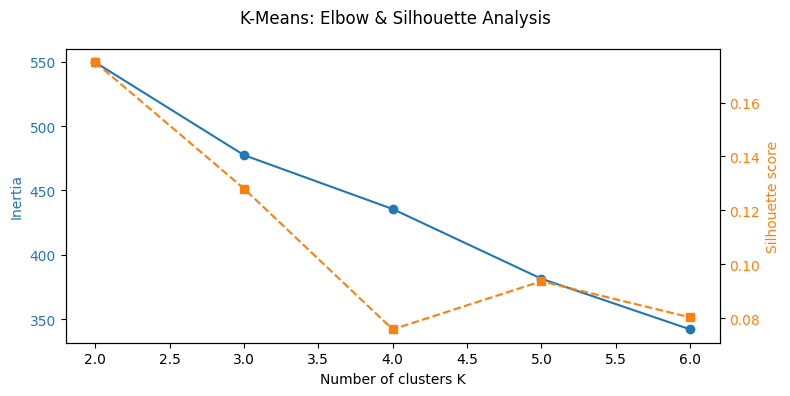

Mean emotion ratings per cluster:


,Frustrated,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
Cluster,,,,,,,,,,,
0,3.075,1.575000,1.075,2.600000,1.400000,2.6,1.425000,3.212500,1.025000,3.187500,3.325
1,3.625,1.958333,1.250,3.041667,1.416667,2.0,1.541667,3.833333,1.166667,3.583333,3.625



Role (Puzzler) distribution by cluster:
Cluster  Puzzler
0        0          10
         1          10
1        0           3
         1           3
Name: count, dtype: int64

Cohort distribution by cluster:
Cluster  Cohort
0        D1_1      8
         D1_3      4
         D1_4      4
         D1_5      2
         D1_6      2
1        D1_2      6
Name: count, dtype: int64

Cluster sizes:
Cluster
0    20
1     6
Name: count, dtype: int64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


Ks = range(2, 7)
inertias = []
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_reduced, labels))
    print(f"K={k:>1d}  inertia={km.inertia_:.1f}  silhouette={sil_scores[-1]:.3f}")


fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(Ks, inertias, 'o-', label='Inertia')
ax1.set_xlabel('Number of clusters K')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(Ks, sil_scores, 's--', color='tab:orange', label='Silhouette')
ax2.set_ylabel('Silhouette score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.suptitle('K-Means: Elbow & Silhouette Analysis')
fig.tight_layout()
plt.show()


K_opt = 2
kmeans_opt = KMeans(n_clusters=K_opt, random_state=42, n_init=10).fit(X_reduced)
labels_opt = kmeans_opt.labels_

aux['Cluster'] = labels_opt

# 1) Mean emotion ratings per cluster
emotion_means = aux.groupby('Cluster')[emotion_cols].mean()
print("Mean emotion ratings per cluster:")
display(emotion_means)

# 2) Metadata distribution per cluster
print("\nRole (Puzzler) distribution by cluster:")
print(aux.groupby('Cluster')['Puzzler'].value_counts())

print("\nCohort distribution by cluster:")
print(aux.groupby('Cluster')['Cohort'].value_counts())

# 3) Cluster sizes
print("\nCluster sizes:")
print(aux['Cluster'].value_counts().sort_index())



In [ ]:
import pandas as pd
from sklearn.cluster import KMeans


kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_reduced)
labels_2 = kmeans_2.labels_


aux['Cluster'] = labels_2

# Physiological centroids (in Z-score space)
centroids = pd.DataFrame(
    kmeans_2.cluster_centers_,
    columns=X_reduced.columns,
    index=[f"Cluster {i}" for i in range(2)]
)
print("Physiological centroids (Z-scores):")
display(centroids)

# Mean emotion ratings per cluster

emotion_means = aux.groupby('Cluster')[emotion_cols].mean()
print("\nMean self-reported emotions per cluster:")
display(emotion_means)

print("\n‘Puzzler’ role counts by cluster:")
print(aux.groupby('Cluster')['Puzzler'].value_counts())

print("\n‘Cohort’ counts by cluster:")
print(aux.groupby('Cluster')['Cohort'].value_counts())

print("\nCluster sizes:")
print(aux['Cluster'].value_counts().sort_index())


Physiological centroids (Z-scores):


,EDA_TD_P_AUC,EDA_TD_P_Kurtosis,EDA_TD_P_Min,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT,EDA_TD_T_AUC,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope,...,HR_TD_Slope_max,HR_TD_Slope_min,TEMP_TD_AUC,TEMP_TD_Kurtosis,TEMP_TD_Max,TEMP_TD_Skew,TEMP_TD_Slope,TEMP_TD_Slope_max,TEMP_TD_Slope_min,TEMP_TD_std
Cluster 0,-0.376061,0.294632,0.145809,-0.226261,0.230617,0.387456,-0.391638,-0.208712,0.265318,0.060204,...,-0.027922,0.089149,-0.225780,-0.209592,-0.381089,0.264108,-0.053676,0.103947,-0.011891,0.142730
Cluster 1,1.253536,-0.982107,-0.486031,0.754202,-0.768724,-1.291520,1.305460,0.695707,-0.884393,-0.200681,...,0.093073,-0.297164,0.752601,0.698641,1.270298,-0.880360,0.178921,-0.346490,0.039638,-0.475768



Mean self-reported emotions per cluster:


,Frustrated,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
Cluster,,,,,,,,,,,
0,3.075,1.575000,1.075,2.600000,1.400000,2.6,1.425000,3.212500,1.025000,3.187500,3.325
1,3.625,1.958333,1.250,3.041667,1.416667,2.0,1.541667,3.833333,1.166667,3.583333,3.625



‘Puzzler’ role counts by cluster:
Cluster  Puzzler
0        0          10
         1          10
1        0           3
         1           3
Name: count, dtype: int64

‘Cohort’ counts by cluster:
Cluster  Cohort
0        D1_1      8
         D1_3      4
         D1_4      4
         D1_5      2
         D1_6      2
1        D1_2      6
Name: count, dtype: int64

Cluster sizes:
Cluster
0    20
1     6
Name: count, dtype: int64


Now, drop the cohort to see if the clusters persist

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = X_reduced.columns.tolist()

# Batch‐correction (just in case)
X_bc = X_reduced.copy()
X_bc['Cohort'] = aux['Cohort']
X_corrected = X_bc.groupby('Cohort')[features] \
                .transform(lambda col: (col - col.mean()) / col.std(ddof=0)) \
                .set_index(X_reduced.index)

# Global scaling
scaler = StandardScaler()
X_bc_scaled = pd.DataFrame(
    scaler.fit_transform(X_corrected),
    index=X_corrected.index,
    columns=features
)

# Drop the same feature as before
to_drop = ['TEMP_TD_Max']
X_bc_reduced = X_bc_scaled.drop(columns=to_drop)

# 2) Fit final K=2 clustering
kmeans_bc = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_bc_reduced)
aux['Cluster_bc'] = kmeans_bc.labels_

# 3) Physiological centroids
centroids_bc = pd.DataFrame(
    kmeans_bc.cluster_centers_,
    columns=X_bc_reduced.columns,
    index=['Cluster 0','Cluster 1']
)
print("Batch-Corrected Physiological Centroids (Z-scores):")
display(centroids_bc)

# 4) Mean self-reported emotions per batch-corrected cluster
for col in emotion_cols:
    aux[col] = pd.to_numeric(aux[col], errors='coerce')

emotion_means_bc = aux.groupby('Cluster_bc')[emotion_cols].mean()
print("\nMean self-reported emotions by batch-corrected cluster:")
display(emotion_means_bc)


Batch-Corrected Physiological Centroids (Z-scores):


,EDA_TD_P_AUC,EDA_TD_P_Kurtosis,EDA_TD_P_Min,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT,EDA_TD_T_AUC,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope,...,HR_TD_Slope,HR_TD_Slope_max,HR_TD_Slope_min,TEMP_TD_AUC,TEMP_TD_Kurtosis,TEMP_TD_Skew,TEMP_TD_Slope,TEMP_TD_Slope_max,TEMP_TD_Slope_min,TEMP_TD_std
Cluster 0,0.404669,-0.314951,0.183469,0.504441,-0.101107,-0.507244,0.383014,-0.427612,0.188625,0.166958,...,-0.161073,0.122960,0.005190,-0.113953,-0.286117,0.029539,-0.278137,0.148766,-0.158713,0.205697
Cluster 1,-0.764375,0.594908,-0.346553,-0.952834,0.190981,0.958128,-0.723471,0.807712,-0.356291,-0.315366,...,0.304250,-0.232259,-0.009803,0.215245,0.540443,-0.055797,0.525369,-0.281002,0.299791,-0.388539



Mean self-reported emotions by batch-corrected cluster:


,Frustrated,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
Cluster_bc,,,,,,,,,,,
0,3.308824,1.75,1.132353,2.558824,1.367647,2.426471,1.323529,3.352941,1.000000,3.294118,3.338235
1,3.000000,1.50,1.083333,2.972222,1.472222,2.527778,1.694444,3.361111,1.166667,3.250000,3.500000


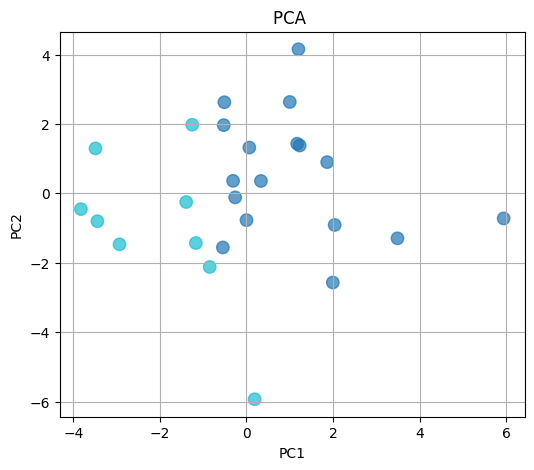

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Xc = X_bc_reduced; labels = aux['Cluster_bc']
pca = PCA(n_components=2)
pc = pca.fit_transform(Xc)

plt.figure(figsize=(6,5))
plt.scatter(pc[:,0], pc[:,1], c=labels, cmap='tab10', s=80, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA ')
plt.grid(True)
plt.show()


Compare the clusters in different phases, to see if they persist

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

df = pd.read_csv("HR_data.csv")
def make_phase_clusters(phase_key, K=2):

    sub = df[df['Phase']==phase_key]
    numeric = sub.select_dtypes(include=np.number).columns.difference(
        ['Unnamed: 0','Individual','Puzzler','Cohort']
    )
    agg_phy = sub.groupby('Individual')[numeric].mean()
    agg_meta = sub.groupby('Individual')[['Cohort']].first()
    agg = agg_phy.merge(agg_meta, left_index=True, right_index=True)

    X = agg.drop(columns=['Cohort'])   # keep only physiology
    scaler = StandardScaler()
    Xs = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)
    corr = Xs.corr().abs()
    up = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop = [c for c in up.columns if any(up[c]>0.85)]
    Xr = Xs.drop(columns=drop)


    km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(Xr)
    return pd.Series(km.labels_, index=Xr.index, name=f'cluster_{phase_key}')

labels = pd.concat([
    make_phase_clusters('phase1'),
    make_phase_clusters('phase2'),
    make_phase_clusters('phase3'),
], axis=1)

# 2. Compute ARI between each pair
ari_1_2 = adjusted_rand_score(labels['cluster_phase1'], labels['cluster_phase2'])
ari_2_3 = adjusted_rand_score(labels['cluster_phase2'], labels['cluster_phase3'])
ari_1_3 = adjusted_rand_score(labels['cluster_phase1'], labels['cluster_phase3'])

print("ARI phase1 vs phase2:", ari_1_2)
print("ARI phase2 vs phase3:", ari_2_3)
print("ARI phase1 vs phase3:", ari_1_3)

# 3. Inspect transitions
print(labels.value_counts().sort_index())

df = pd.read_csv("HR_data.csv")


ARI phase1 vs phase2: 0.5542192624987575
ARI phase2 vs phase3: 0.16882992019998078
ARI phase1 vs phase3: 0.2536170864273138
cluster_phase1  cluster_phase2  cluster_phase3
0               0               0                 14
                                1                  4
                1               0                  1
1               0               0                  1
                                1                  1
                1               0                  1
                                1                  4
Name: count, dtype: int64
